### Graph 3 

In [2]:
from typing import List,TypedDict
from langgraph.graph import StateGraph

In [3]:
class AgentState(TypedDict):
    name : str
    age : str
    final : str

In [4]:
def first_node(state:AgentState)->AgentState:
    """this is the first node of the sequence"""
    state['final']= f"hi {state['name']}"

    return state

def second_node(state:AgentState)->AgentState:
    """this is the second node of the sequence"""
    state['final'] = state['final']+f"you are {state['age']} years old"
    return state

In [9]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("sec_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "sec_node")
graph.set_finish_point("sec_node")

app = graph.compile()

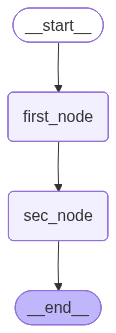

In [10]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))


In [11]:
result = app.invoke({"name":"charlie","age":"19"})
result

{'name': 'charlie', 'age': '19', 'final': 'hi charlieyou are 19 years old'}